# DDIM v2 — AdamW Optimizer

Reproduces the best DDIM (`ddim_full_ep100_seed42`, FID=45.01) with a single change:

| | v1 (baseline) | v2 |
|---|---|---|
| Optimizer | Adam | **AdamW** |
| lr | 2e-4 | 2e-4 |
| weight_decay | — | **1e-4** |
| Everything else | unchanged | unchanged |

**Hypothesis:** AdamW's decoupled weight decay acts as a mild regulariser on the UNet weights, potentially improving generalisation and FID.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [2]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR = WORKSPACE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)
print('RUNS_DIR       =', RUNS_DIR)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data
RUNS_DIR       = c:\Users\User\source\repos\genai-project1\runs


In [4]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf  = hf_ds["test"]

print("Train size:", len(train_hf))
print("Test size :", len(test_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Test size : 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


In [7]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, subsets=50, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [8]:
# ── FID/KID evaluation — shared config & helpers ─────────────────
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs        = RUNS_DIR if "RUNS_DIR" in globals() else Path("runs")
_results_out = _runs / "evaluation_results.json"


def _best_row(csv_path, key_col, lower_is_better=True):
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


def _load_results():
    if _results_out.exists():
        with open(_results_out) as f:
            return _json.load(f)
    return {}


def _save_results(d):
    _runs.mkdir(parents=True, exist_ok=True)
    with open(_results_out, "w") as f:
        _json.dump(d, f, indent=2)
    print(f"Saved → {_results_out}")


def _print_results(d):
    if not d:
        print("No results yet.")
        return
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in d.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )

print("FID/KID config ready. Run each model cell independently.")
print(f"Results file: {_results_out}")
if _results_out.exists():
    _print_results(_load_results())


FID/KID config ready. Run each model cell independently.
Results file: c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              195.70     1.00     185.9775       1.3450
DCGAN_FULL       202.48     0.69      91.7944       1.1543
DDPM_FULL         69.46     0.87      47.8215       1.1552
DDIM_FULL         45.01     0.48      24.9569       1.1207


In [9]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Full 50k loader — normalized [-1,1] — used by DCGAN, DDPM, DDIM
_transform_full = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])

train_ds_full = HFDatasetTorch(train_hf, transform=_transform_full, indices=None)
train_loader_full = DataLoader(
    train_ds_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Test dataset — unnormalized [0,1] — used by FID/KID evaluation
_transform_eval = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
])
test_ds = HFDatasetTorch(test_hf, transform=_transform_eval, indices=None)

print(f"Full train dataset : {len(train_ds_full):,} images")
print(f"Test dataset       : {len(test_ds):,} images")
print(f"Batches per epoch  : {len(train_loader_full)}")


Full train dataset : 50,000 images
Test dataset       : 10,000 images
Batches per epoch  : 782


---
# DDPM / DDIM — Class Definitions

Identical to Full_training.ipynb — no architectural changes.

In [10]:
"""DDPM for ArtBench-10."""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def sinusoidal_embeddings(n_steps: int, dim: int) -> torch.Tensor:
    """Fixed sinusoidal embeddings table (interleaved sin/cos), shape (n_steps, dim)."""
    emb = torch.zeros(n_steps, dim)
    position = torch.arange(0, n_steps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
    emb[:, 0::2] = torch.sin(position * div_term)
    emb[:, 1::2] = torch.cos(position * div_term)
    return emb


def _get_groups(channels: int, num_groups: int = 8) -> int:
    """Find largest divisor of channels that is <= num_groups."""
    g = max(1, min(num_groups, channels))
    while channels % g != 0:
        g -= 1
    return g


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, num_groups: int = 8, dropout: float = 0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(_get_groups(in_channels, num_groups), in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_emb_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = nn.GroupNorm(_get_groups(out_channels, num_groups), out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_emb_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)


class DownBlock(nn.Module):
    """Two ResBlocks (maintain channels) + strided conv that changes channels."""

    def __init__(self, channels: int, next_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.res1 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.down = nn.Conv2d(channels, next_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor):
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        skip = x          # saved before downsampling, at original channels
        x = self.down(x)  # spatial downsample + channel change
        return x, skip


class UpBlock(nn.Module):
    """Transposed conv + concat skip + two ResBlocks."""

    def __init__(self, in_channels: int, out_channels: int, skip_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res1 = ResBlock(out_channels + skip_channels, out_channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(out_channels, out_channels, time_emb_dim, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor, time_emb: torch.Tensor):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        return x


class UNet(nn.Module):
    """UNet for diffusion denoising. Structurally identical to UNet32 from Antonio's notebook."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        dropout: float = 0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256]

        self.time_emb_dim = time_emb_dim
        self.hidden_dims = hidden_dims

        # Timestep embedding: fixed sinusoidal lookup, then MLP
        embed_dim = hidden_dims[0]
        self.time_embed = nn.Embedding(num_steps, embed_dim)
        self.time_embed.weight.data = sinusoidal_embeddings(num_steps, embed_dim)
        self.time_embed.weight.requires_grad = False

        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.initial_conv = nn.Conv2d(img_channels, hidden_dims[0], kernel_size=3, padding=1)

        # Down path: len(hidden_dims) levels, 32 -> 16 -> 8 -> 4
        # Channels at each level: hidden_dims[i]
        # Downsampling conv changes to hidden_dims[i+1] (last level stays same)
        self.downs = nn.ModuleList()
        for i, ch in enumerate(hidden_dims):
            next_ch = hidden_dims[i + 1] if i < len(hidden_dims) - 1 else hidden_dims[-1]
            self.downs.append(DownBlock(ch, next_ch, time_emb_dim, dropout=dropout))

        # Bottleneck at 4x4
        self.mid1 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)
        self.mid2 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)

        # Up path: len(hidden_dims) levels, 4 -> 8 -> 16 -> 32
        # skip channels = hidden_dims reversed (d3=256, d2=128, d1=64)
        # upsample channel pattern: 256->256->128->64
        self.ups = nn.ModuleList()
        rev = list(reversed(hidden_dims))   # [256, 128, 64]
        in_ch = hidden_dims[-1]
        for i, skip_ch in enumerate(rev):
            out_ch = rev[i]
            self.ups.append(UpBlock(in_ch, out_ch, skip_ch, time_emb_dim, dropout=dropout))
            in_ch = out_ch

        # Final output: GroupNorm + SiLU + Conv
        out_ch = hidden_dims[0]
        self.out = nn.Sequential(
            nn.GroupNorm(_get_groups(out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Noisy image (B, C, H, W)
            t: Timestep indices (B,) as long integers

        Returns:
            predicted_noise: (B, C, H, W)
        """
        t_emb = self.time_mlp(self.time_embed(t.long()))

        x = self.initial_conv(x)

        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)


class DiffusionScheduler(nn.Module):
    """Linear diffusion schedule with registered buffers."""

    def __init__(self, num_steps: int = 1000, beta_start: float = 1e-4, beta_end: float = 2e-2):
        super().__init__()

        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alpha_cumprod = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat([torch.ones(1), alpha_cumprod[:-1]], dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("alpha_cumprod_prev", alpha_cumprod_prev)

        self.register_buffer("sqrt_alpha_cumprod", torch.sqrt(alpha_cumprod))
        self.register_buffer("sqrt_one_minus_alpha_cumprod", torch.sqrt(1.0 - alpha_cumprod))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alphas))

        posterior_variance = betas * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod)
        self.register_buffer("posterior_variance", torch.clamp(posterior_variance, min=1e-20))

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise"""
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x_0
            + self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1) * noise
        )


class Diffusion(nn.Module):
    """DDPM — Denoising Diffusion Probabilistic Models (Ho et al. 2020)."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.num_steps = num_steps

        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims,
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )

        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        shape: tuple = (3, 32, 32),
        device: torch.device | str | None = None,
        num_inference_steps: int | None = None,
    ) -> torch.Tensor:
        """Generate samples via reverse diffusion. Returns images in [0, 1]."""
        self.eval()

        if device is None:
            device = next(self.parameters()).device
        if isinstance(device, str):
            device = torch.device(device)

        if num_inference_steps is None:
            timesteps = torch.arange(self.num_steps - 1, -1, -1, device=device)
        else:
            timesteps = torch.linspace(self.num_steps - 1, 0, num_inference_steps, device=device).long()

        x = torch.randn(num_samples, *shape, device=device)

        for t_scalar in timesteps:
            t_idx = int(t_scalar.item())
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)

            beta_t = self.scheduler.betas[t_idx].view(1, 1, 1, 1)
            sqrt_one_minus_abar = self.scheduler.sqrt_one_minus_alpha_cumprod[t_idx].view(1, 1, 1, 1)
            sqrt_recip_alpha = self.scheduler.sqrt_recip_alphas[t_idx].view(1, 1, 1, 1)

            pred_noise = self.unet(x, t)
            model_mean = sqrt_recip_alpha * (x - beta_t * pred_noise / (sqrt_one_minus_abar + 1e-8))

            if t_idx > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

        return torch.clamp(x, 0, 1)


In [11]:
"""DDIM — Denoising Diffusion Implicit Models.

Training is identical to DDPM (predict noise, MSE loss).
Sampling is deterministic (eta=0) using a subsequence of timesteps.
Reuses UNet, DiffusionScheduler, and sinusoidal_embeddings from the DDPM section.
"""


class DDIM(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_steps = num_steps
        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims or [64, 128, 256],
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )
        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        """Training forward: same as DDPM."""
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(self, num_samples: int, shape: tuple, device, num_inference_steps: int = 200) -> torch.Tensor:
        """Deterministic DDIM sampling (eta=0)."""
        self.eval()
        abar = self.scheduler.alpha_cumprod.to(device)

        # evenly spaced subsequence T-1 → 0
        step = max(1, self.num_steps // num_inference_steps)
        timesteps = torch.arange(self.num_steps - 1, -1, -step, device=device)[:num_inference_steps]

        x = torch.randn(num_samples, *shape, device=device)

        for i, t_scalar in enumerate(timesteps):
            t_idx      = int(t_scalar.item())
            t_prev_idx = int(timesteps[i + 1].item()) if i + 1 < len(timesteps) else -1

            abar_t    = abar[t_idx]
            abar_prev = abar[t_prev_idx] if t_prev_idx >= 0 else torch.ones(1, device=device).squeeze()

            t_batch = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)
            eps = self.unet(x, t_batch)

            # predicted x0
            x0_pred = (x - torch.sqrt(1 - abar_t) * eps) / (torch.sqrt(abar_t) + 1e-8)
            x0_pred = x0_pred.clamp(-1, 1)

            # DDIM step (deterministic)
            x = torch.sqrt(abar_prev) * x0_pred + torch.sqrt(1 - abar_prev) * eps

        return x.clamp(0, 1)


## Train DDIM v2 — AdamW (50k, 100 epochs)

Device: cuda
Train size: 50,000 | Epochs: 100

Starting: ddim_v2_adamw_ep100_seed42 (50,000 images)
[DDIM-v2-AdamW] Epoch   1/100 | train_loss=0.0823
[DDIM-v2-AdamW] Epoch   2/100 | train_loss=0.0464
[DDIM-v2-AdamW] Epoch   3/100 | train_loss=0.0422
[DDIM-v2-AdamW] Epoch   4/100 | train_loss=0.0403
[DDIM-v2-AdamW] Epoch   5/100 | train_loss=0.0379
[DDIM-v2-AdamW] Epoch   6/100 | train_loss=0.0376
[DDIM-v2-AdamW] Epoch   7/100 | train_loss=0.0367
[DDIM-v2-AdamW] Epoch   8/100 | train_loss=0.0368
[DDIM-v2-AdamW] Epoch   9/100 | train_loss=0.0357
[DDIM-v2-AdamW] Epoch  10/100 | train_loss=0.0358
[DDIM-v2-AdamW] Epoch  11/100 | train_loss=0.0352
[DDIM-v2-AdamW] Epoch  12/100 | train_loss=0.0356
[DDIM-v2-AdamW] Epoch  13/100 | train_loss=0.0349
[DDIM-v2-AdamW] Epoch  14/100 | train_loss=0.0347
[DDIM-v2-AdamW] Epoch  15/100 | train_loss=0.0346
[DDIM-v2-AdamW] Epoch  16/100 | train_loss=0.0349
[DDIM-v2-AdamW] Epoch  17/100 | train_loss=0.0348
[DDIM-v2-AdamW] Epoch  18/100 | train_loss=0.0349


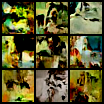

[DDIM-v2-AdamW] Epoch  25/100 | train_loss=0.0347
[DDIM-v2-AdamW] Epoch  26/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  27/100 | train_loss=0.0344
[DDIM-v2-AdamW] Epoch  28/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  29/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  30/100 | train_loss=0.0343
[DDIM-v2-AdamW] Epoch  31/100 | train_loss=0.0341
[DDIM-v2-AdamW] Epoch  32/100 | train_loss=0.0340
[DDIM-v2-AdamW] Epoch  33/100 | train_loss=0.0342
[DDIM-v2-AdamW] Epoch  34/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  35/100 | train_loss=0.0339
[DDIM-v2-AdamW] Epoch  36/100 | train_loss=0.0341
[DDIM-v2-AdamW] Epoch  37/100 | train_loss=0.0335
[DDIM-v2-AdamW] Epoch  38/100 | train_loss=0.0334
[DDIM-v2-AdamW] Epoch  39/100 | train_loss=0.0333
[DDIM-v2-AdamW] Epoch  40/100 | train_loss=0.0338
[DDIM-v2-AdamW] Epoch  41/100 | train_loss=0.0336
[DDIM-v2-AdamW] Epoch  42/100 | train_loss=0.0341
[DDIM-v2-AdamW] Epoch  43/100 | train_loss=0.0338
[DDIM-v2-AdamW] Epoch  44/100 | train_loss=0.0345


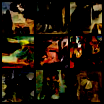

[DDIM-v2-AdamW] Epoch  50/100 | train_loss=0.0339
[DDIM-v2-AdamW] Epoch  51/100 | train_loss=0.0331
[DDIM-v2-AdamW] Epoch  52/100 | train_loss=0.0329
[DDIM-v2-AdamW] Epoch  53/100 | train_loss=0.0341
[DDIM-v2-AdamW] Epoch  54/100 | train_loss=0.0338
[DDIM-v2-AdamW] Epoch  55/100 | train_loss=0.0332
[DDIM-v2-AdamW] Epoch  56/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  57/100 | train_loss=0.0332
[DDIM-v2-AdamW] Epoch  58/100 | train_loss=0.0335
[DDIM-v2-AdamW] Epoch  59/100 | train_loss=0.0332
[DDIM-v2-AdamW] Epoch  60/100 | train_loss=0.0336
[DDIM-v2-AdamW] Epoch  61/100 | train_loss=0.0329
[DDIM-v2-AdamW] Epoch  62/100 | train_loss=0.0335
[DDIM-v2-AdamW] Epoch  63/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  64/100 | train_loss=0.0334
[DDIM-v2-AdamW] Epoch  65/100 | train_loss=0.0333
[DDIM-v2-AdamW] Epoch  66/100 | train_loss=0.0334
[DDIM-v2-AdamW] Epoch  67/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  68/100 | train_loss=0.0338
[DDIM-v2-AdamW] Epoch  69/100 | train_loss=0.0336


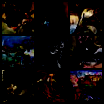

[DDIM-v2-AdamW] Epoch  75/100 | train_loss=0.0334
[DDIM-v2-AdamW] Epoch  76/100 | train_loss=0.0339
[DDIM-v2-AdamW] Epoch  77/100 | train_loss=0.0331
[DDIM-v2-AdamW] Epoch  78/100 | train_loss=0.0330
[DDIM-v2-AdamW] Epoch  79/100 | train_loss=0.0332
[DDIM-v2-AdamW] Epoch  80/100 | train_loss=0.0336
[DDIM-v2-AdamW] Epoch  81/100 | train_loss=0.0332
[DDIM-v2-AdamW] Epoch  82/100 | train_loss=0.0337
[DDIM-v2-AdamW] Epoch  83/100 | train_loss=0.0328
[DDIM-v2-AdamW] Epoch  84/100 | train_loss=0.0331
[DDIM-v2-AdamW] Epoch  85/100 | train_loss=0.0327
[DDIM-v2-AdamW] Epoch  86/100 | train_loss=0.0331
[DDIM-v2-AdamW] Epoch  87/100 | train_loss=0.0331
[DDIM-v2-AdamW] Epoch  88/100 | train_loss=0.0326
[DDIM-v2-AdamW] Epoch  89/100 | train_loss=0.0328
[DDIM-v2-AdamW] Epoch  90/100 | train_loss=0.0330
[DDIM-v2-AdamW] Epoch  91/100 | train_loss=0.0330
[DDIM-v2-AdamW] Epoch  92/100 | train_loss=0.0328
[DDIM-v2-AdamW] Epoch  93/100 | train_loss=0.0329
[DDIM-v2-AdamW] Epoch  94/100 | train_loss=0.0332


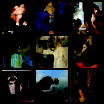

[DDIM-v2-AdamW] Epoch 100/100 | train_loss=0.0328

Finished ddim_v2_adamw_ep100_seed42 | best_loss=0.0324 @ epoch 96 | time=128.7 min
Summary: c:\Users\User\source\repos\genai-project1\runs\ddim_v2_adamw_summary.csv


In [12]:
import os, gc, json, time, csv
from pathlib import Path
import torch
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display as ipy_display, Image as IPyImage
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

base_runs_dir = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────
ddim_hidden_dims    = [64, 128, 256]
ddim_time_emb_dim   = 256
num_epochs          = 100
learning_rate       = 2e-4
num_diffusion_steps = 1000
ddim_infer_steps    = 200
img_channels        = 3
img_size            = IMAGE_SIZE

summary_csv_path = base_runs_dir / "ddim_v2_adamw_summary.csv"

print(f"Train size: {len(train_loader_full.dataset):,} | Epochs: {num_epochs}")


def train_ddim_full():
    run_name = f"ddim_v2_adamw_ep{num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir    = run_dir / "checkpoints"; ckpt_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = run_dir / "samples";     samples_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt   = ckpt_dir / "best_model.pt"
    final_ckpt  = ckpt_dir / "final_model.pt"
    metrics_csv = run_dir / "metrics.csv"

    config = {
        "run_name": run_name, "num_epochs": num_epochs,
        "learning_rate": learning_rate, "img_channels": img_channels,
        "img_size": img_size, "hidden_dims": ddim_hidden_dims,
        "time_emb_dim": ddim_time_emb_dim,
        "num_diffusion_steps": num_diffusion_steps,
        "ddim_infer_steps": ddim_infer_steps,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
    }
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    model = DDIM(
        img_channels=img_channels, hidden_dims=ddim_hidden_dims,
        time_emb_dim=ddim_time_emb_dim, num_steps=num_diffusion_steps,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate,
                           weight_decay=1e-4)  # AdamW: decoupled L2 reg

    with open(metrics_csv, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writeheader()

    best_loss  = float("inf")
    best_epoch = -1
    start_time = time.time()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name} ({len(train_loader_full.dataset):,} images)")
    print("=" * 100)

    for epoch in range(num_epochs):
        model.train()
        loss_sum, n_batches = 0.0, 0

        for batch in train_loader_full:
            x0    = batch[0].to(device, non_blocking=True)
            t     = torch.randint(0, num_diffusion_steps, (x0.size(0),), device=device).long()
            noise = torch.randn_like(x0)

            pred_noise = model(x0, t, noise)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum  += loss.item()
            n_batches += 1

        train_loss = loss_sum / max(n_batches, 1)

        with open(metrics_csv, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writerow(
                {"epoch": epoch + 1, "train_loss": train_loss})

        if train_loss < best_loss:
            best_loss  = train_loss
            best_epoch = epoch + 1
            torch.save({"epoch": best_epoch, "model_state_dict": model.state_dict(),
                        "best_train_loss": best_loss, "config": config}, best_ckpt)

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                _imgs = model.sample(9, (img_channels, img_size, img_size),
                                     device, ddim_infer_steps)
            sp = samples_dir / f"epoch_{epoch+1:03d}.png"
            save_image(make_grid(_imgs, nrow=3, padding=2), sp)
            print(f"Samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sp), width=400))

        print(f"[DDIM-v2-AdamW] Epoch {epoch+1:>3}/{num_epochs} | train_loss={train_loss:.4f}")

    total_time = time.time() - start_time

    torch.save({"epoch": num_epochs, "model_state_dict": model.state_dict(),
                "best_train_loss": best_loss, "best_epoch": best_epoch,
                "config": config}, final_ckpt)

    summary_row = {
        "run_name": run_name, "num_epochs": num_epochs,
        "best_epoch": best_epoch, "best_train_loss": best_loss,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
        "run_dir": str(run_dir), "best_ckpt_path": str(best_ckpt),
        "final_ckpt_path": str(final_ckpt),
        "time_sec": total_time, "status": "ok",
    }
    print(f"\nFinished {run_name} | best_loss={best_loss:.4f} @ epoch {best_epoch} | time={total_time/60:.1f} min")
    return summary_row


summary_fieldnames = [
    "run_name", "num_epochs", "best_epoch", "best_train_loss",
    "train_size", "batch_size", "run_dir",
    "best_ckpt_path", "final_ckpt_path", "time_sec", "status",
]

with open(summary_csv_path, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writeheader()

try:
    result = train_ddim_full()
except RuntimeError as e:
    result = {k: None for k in summary_fieldnames}
    result.update({"status": f"error: {e}",
                   "run_name": f"ddim_full_ep{num_epochs}_seed{seed}"})
    print(f"Training failed: {e}")

with open(summary_csv_path, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writerow(result)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"Summary: {summary_csv_path}")


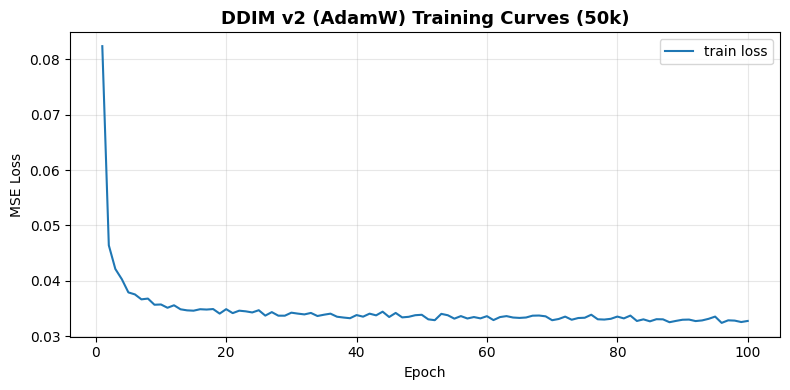

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v2_adamw_training_curves.png


In [13]:
# DDIM Full — Loss Curves
import csv, matplotlib.pyplot as plt
from pathlib import Path

_runs    = RUNS_DIR
_metrics = _runs / "ddim_v2_adamw_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, loss = [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            loss.append(float(row["train_loss"]))

    plt.figure(figsize=(8, 4))
    plt.plot(ep, loss, label="train loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("DDIM v2 (AdamW) Training Curves (50k)", fontsize=13, fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = _runs / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "ddim_v2_adamw_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'ddim_v2_adamw_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Loaded epoch 96 | best_train_loss=0.03243047663765719
Inference (36 samples, 200 steps): 3.10s | 86.0 ms/image
Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v2_adamw_samples.png


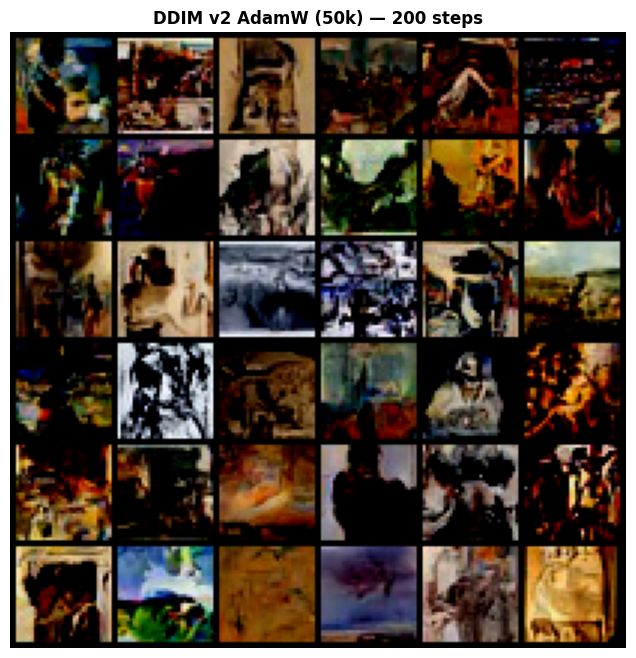

In [14]:
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid, save_image
from pathlib import Path

base_runs_dir = RUNS_DIR
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs    = 100; seed = 42; ddim_infer_steps = 200

_best  = base_runs_dir / "ddim_v2_adamw_ep100_seed42" / "checkpoints" / "best_model.pt"
_final = base_runs_dir / "ddim_v2_adamw_ep100_seed42" / "checkpoints" / "final_model.pt"
ckpt_path = _best if _best.exists() else _final

if not ckpt_path.exists():
    print(f"Checkpoint not found. Run training first.")
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg  = ckpt["config"]
    model = DDIM(
        img_channels=cfg["img_channels"], hidden_dims=cfg["hidden_dims"],
        time_emb_dim=cfg["time_emb_dim"], num_steps=cfg["num_diffusion_steps"],
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    best_loss = ckpt.get("best_train_loss", "?")
    print(f"Loaded epoch {ckpt['epoch']} | best_train_loss={best_loss}")

    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():
        _ = model.sample(1, (cfg["img_channels"], cfg["img_size"], cfg["img_size"]),
                         device, ddim_infer_steps)  # warmup
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = model.sample(36, (cfg["img_channels"], cfg["img_size"], cfg["img_size"]),
                               device, ddim_infer_steps)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference (36 samples, {ddim_infer_steps} steps): {_infer_time:.2f}s | {_infer_time/36*1000:.1f} ms/image")

    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["ddim_v2_adamw"] = {"time_36_samples_sec": round(_infer_time, 4),
                        "ms_per_image": round(_infer_time/36*1000, 2)}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    imgs = samples.clamp(0, 1)
    grid = make_grid(imgs[:36], nrow=6, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(f"DDIM v2 AdamW (50k) — {ddim_infer_steps} steps", fontsize=12, fontweight="bold")
    _fig_dir = base_runs_dir / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "ddim_v2_adamw_samples.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {_fig_dir / 'ddim_v2_adamw_samples.png'}")
    plt.show()


In [15]:
# ── DDIM Full — FID/KID (professor protocol: 50 subsets × 100) ──
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import numpy as np

_best  = _runs / "ddim_v2_adamw_ep100_seed42" / "checkpoints" / "best_model.pt"
_final = _runs / "ddim_v2_adamw_ep100_seed42" / "checkpoints" / "final_model.pt"
_ckpt_path = _best if _best.exists() else _final

DDIM_FULL_INFER_STEPS = 200

if _ckpt_path.exists():
    print(f"[DDIM-full] Loading from: {_ckpt_path}")
    _ckpt  = torch.load(_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = DDIM(
        img_channels=_cfg["img_channels"], hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"], num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="diffusion",
        latent_dim=0, img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
        num_inference_steps=DDIM_FULL_INFER_STEPS,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["ddim_v2_adamw"] = _res
    _save_results(_all)
    _print_results({"ddim_v2_adamw": _res})

    # ── Subset vs Full comparison ─────────────────────────────────
    print("\n── Subset vs Full dataset ───────────────────────────────────")
    print(f"{'Config':<30} {'FID':>8} {'FID±':>7} {'KID×10³':>10}")
    print("-" * 60)
    for key, label in [
        ("ddim_full",      "DDIM v1 Adam   (50k, 200 steps)"),
        ("ddim_v2_adamw", "DDIM v2 AdamW (50k, 200 steps)"),
    ]:
        if key in _all:
            r = _all[key]
            print(f"{label:<30} {r['fid_mean']:>8.2f} {r['fid_std']:>7.2f} {r['kid_mean']*1e3:>10.2f}")
else:
    print(f"[DDIM-full] Checkpoint not found — run training first.")


[DDIM-full] Loading from: c:\Users\User\source\repos\genai-project1\runs\ddim_v2_adamw_ep100_seed42\checkpoints\best_model.pt


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [diffusion] Rep 1/10 seed=0 | FID=44.56 | KID=24.4233±4.7171 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=44.90 | KID=24.5904±4.2676 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=45.70 | KID=24.6806±5.0210 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=45.26 | KID=26.4303±5.1522 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=44.86 | KID=24.7071±4.2136 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=44.63 | KID=23.4937±4.7046 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=45.75 | KID=26.5040±4.6979 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=45.97 | KID=27.0072±4.6523 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=44.73 | KID=24.0447±4.3149 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=45.19 | KID=24.5700±3.9783 (×10⁻³)

  DIFFUSION | FID: 45.15 ± 0.48 | KID: 25.0451 ± 1.1122 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
DDIM_V2